### Image classification with Inception_v3 deep learning pre-trained network ###

Fabio Scotti fabio.scotti@unimi.it

Course: Intelligent systems for industry, supply chain and environment


Note. In Colab  you can write shell commands preceded with a ‘!’ within the notebook. It gives us control over the Virtual Machine (VM) to install other non default packages


In [1]:
!pip install -q keras

Any image recognition model available in Keras can be loaded with just two lines of code. 

In [2]:
from keras.applications.inception_v3 import InceptionV3
model = InceptionV3(weights='imagenet', include_top=True)

To start to make Image Classification we can define a fuction predict() with in input the input image and in output the decode predicted output class.

In [3]:
import numpy as np
from keras.preprocessing import image
from keras.applications.inception_v3 import preprocess_input, decode_predictions
from PIL import Image

# prediticton function only for TOP 5 matchings 
def predict(model, img, top_n=5):
         
    # Network Inception_v3 requires resizedinput size, in this case target_size=(299, 299), 
    # The NumPy array is correct for the use with deep learning models
    x = np.expand_dims(img, axis=0)   # required input preparation 

    #  data normalization to zero center the image data using the mean channel values from the training dataset. This is an extremely important step!
    x = preprocess_input(x)  # The preprocess_input function is meant to adequate your image to the format the model requires
    
    # HERE'S THE CLASS PREDICTION  (ONLY TOP top_n)
    preds = model.predict(x)       
    return decode_predictions(preds, top=top_n)[0]



In [4]:
#  click on your own file in the dir e.g. Truck.jpg #
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
 print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
 
 print(fn)

Saving Truck.jpg to Truck (4).jpg
User uploaded file "Truck.jpg" with length 593821 bytes
Truck.jpg


Once you loaded the image, you have to resize to the input size of 299,299 pixels

Truck.jpg


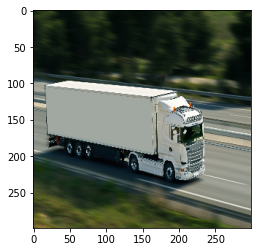

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

img = mpimg.imread(fn)
img  = cv2.resize(img, dsize=(299, 299), interpolation=cv2.INTER_CUBIC)
print(fn)
plt.imshow(img)


Here we have the real predicition 

In [8]:
print(model)
print(fn)

pred = predict(model, img)
print(pred[0])



Truck.jpg
('n03796401', 'moving_van', 0.43757406)


__________________________________
## VISUALIZATIONS ##

Plot the probabilty in the output pred as an image

['moving_van', 'trailer_truck', 'mobile_home', 'recreational_vehicle', 'tow_truck']


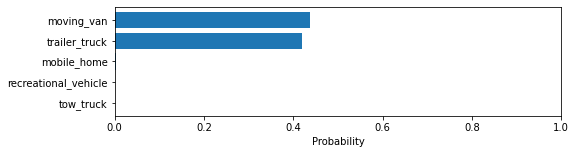

In [9]:
# just for visualization we will use it to plot the output classes as an histogram image
# print as image the bar plot  of the probabilities 
plt.figure(figsize=(8, 2))
classes = [c[1] for c in pred]
probas = [c[2] for c in pred]
y_pos = np.arange(len(classes))
plt.barh(y_pos, probas, align='center')
plt.yticks(y_pos, classes)
plt.gca().invert_yaxis()
plt.xlabel('Probability')
plt.xlim(0, 1)
print(classes)
